# CNN for images

In [177]:
import numpy as np
import pandas as pd

### Load split data

In [178]:
train_df = pd.read_csv(
    "data/train_df.csv",
    parse_dates=["publish_timestamp"]  # converts datestime string into datetime object
)
test_df = pd.read_csv(
    "data/test_df.csv",
    parse_dates=["publish_timestamp"]
)

In [179]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1471 entries, 0 to 1470
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   1471 non-null   int64         
 1   following                 1471 non-null   int64         
 2   publish_timestamp         1471 non-null   datetime64[ns]
 3   has_location              1471 non-null   int64         
 4   is_carousel               1471 non-null   int64         
 5   num_images                1471 non-null   int64         
 6   is_sponsored              1471 non-null   int64         
 7   image_path                1471 non-null   object        
 8   caption                   1443 non-null   object        
 9   follower_following_ratio  1471 non-null   float64       
 10  hour                      1471 non-null   int64         
 11  day                       1471 non-null   object        
 12  is_weekend          

In [180]:
y_train = train_df["engagement_label"].values

y_test = test_df["engagement_label"].values

# Set random seed

In [181]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU

    # Ensure deterministic behavior (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed(42)

### Obtain images

In [182]:
train_df['image_path'].value_counts()

image_path
.\datasets\Data\hardikpandya93_25298326_3015497697586924812_1434924_4335\2023-01-14_11-22-39_UTC.jpg    1
.\datasets\Data\minimalistbaker_2144759_3030046787029914286_2685_25\2023-02-03_13-09-06_UTC_1.jpg       1
.\datasets\Data\minimalistbaker_2144759_3020624944770383934_2613_21\2023-01-21_13-09-35_UTC_1.jpg       1
.\datasets\Data\minimalistbaker_2144759_3019891519067395807_2740_30\2023-01-20_12-52-24_UTC_1.jpg       1
.\datasets\Data\minimalistbaker_2144759_3015554073848571245_2872_20\2023-01-14_13-14-40_UTC_1.jpg       1
                                                                                                       ..
.\datasets\Data\brendonburchard_1158797_3044039991576878179_3441_88\2023-02-22_20-31-06_UTC.jpg         1
.\datasets\Data\brendonburchard_1158797_3043283406079789678_2363_62\2023-02-21_19-27-54_UTC_1.jpg       1
.\datasets\Data\brendonburchard_1158797_3042986395971590589_2528_64\2023-02-21_09-37-48_UTC.jpg         1
.\datasets\Data\brendonburchard_115

### Show an example image

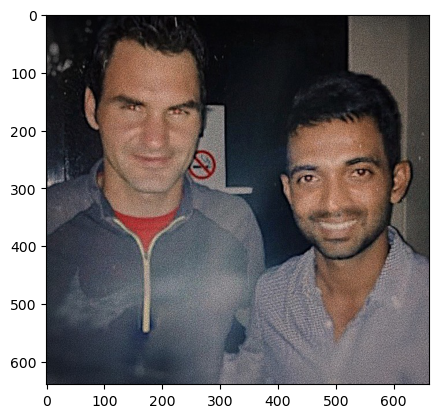

In [183]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(image_path):
    image = mpimg.imread(image_path)
    plt.imshow(image)

show_image(np.random.choice(train_df['image_path'].unique()))

### Define image transforms

In [184]:
from torchvision import transforms

IMAGE_SIZE = 224  # ResNet expects 224x224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),   # data augmentation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],        # ImageNet mean
        std=[0.229, 0.224, 0.225]          # ImageNet std
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


### Create Image Dataset class

In [185]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

class ImageDataset(Dataset):
    def __init__(self, df, img_col="image_path", target_col="engagement_label", transform=None):
        self.df = df.reset_index(drop=True)
        self.img_col = img_col
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # print("Loading image:", self.df.iloc[idx]['image_path'])
        img_path = self.df.loc[idx, self.img_col]
        label = self.df.loc[idx, self.target_col]

        # Load image
        img = Image.open(img_path).convert("RGB")  # make sure it's RGB
        
        if self.transform:
            img = self.transform(img)
        
        return img, label


In [186]:
# train_ds = ImageDataset(train_df, transform=train_transform)
# test_ds  = ImageDataset(test_df, transform=test_transform)

### DataLoader

In [187]:
# batch_size = 32

# train_loader = DataLoader(
#     train_ds,
#     batch_size=batch_size,
#     shuffle=True, # only for training
#     num_workers=0
# )

# test_loader = DataLoader(
#     test_ds,
#     batch_size=batch_size,
#     shuffle=False,
#     num_workers=0
# )


In [188]:
# import torch.nn as nn
# import torch.nn.functional as F

# class SimpleCNN(nn.Module):
#     def __init__(self, num_classes=3):
#         super().__init__()
#         self.conv1 = nn.Conv2d(3, 32, 3, padding=1)  # input 3 channels (RGB)
#         self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
#         self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
#         self.pool = nn.MaxPool2d(2,2)
#         self.dropout = nn.Dropout(0.3)
#         self.fc1 = nn.Linear(128 * 16 * 16, 256)  # adjust if image_size changes
#         self.fc2 = nn.Linear(256, num_classes)

#     def forward(self, x):
#         x = F.relu(self.conv1(x))
#         x = self.pool(x)
#         x = F.relu(self.conv2(x))
#         x = self.pool(x)
#         x = F.relu(self.conv3(x))
#         x = self.pool(x)  # final size (batch, 128, 16,16) if image_size=128
#         x = x.view(x.size(0), -1)
#         x = self.dropout(F.relu(self.fc1(x)))
#         x = self.fc2(x)
#         return x


In [189]:
# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = SimpleCNN(num_classes=3).to(device)
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


### Pretrained ResNet18 for images

In [190]:
import torch.nn as nn 
import torchvision.models as models
import torch.nn.functional as F

resnet = models.resnet18(weights="IMAGENET1K_V1")

class ImageResNet(nn.Module):
    def __init__(self, resnet_model, num_classes=3, dropout=0.5):
        super().__init__()
        self.resnet = resnet_model
        
        # Replace the final fc layer (classifier head)
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.resnet(x)

# # Hyperparameters

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model = ImageResNet(resnet, num_classes=3).to(device)

# criterion = nn.CrossEntropyLoss()
# # optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# optimizer = torch.optim.Adam(
#     model.resnet.fc.parameters(), # only train classifier head when frozen
#     lr=1e-3
# )


In [191]:
# print(model)

### Train and test loop

In [192]:

# training loop
def train_epoch(loader):
    print("Training")
    # Put model in training mode
    model.train()

    # Initialize accumulator for total loss
    total_loss = 0

    # Loops over batches in training set
    for batch in loader:
        # Detect if batch is a dict (BERT-style) or tuple (LSTM/MLP/CNN)
        if isinstance(batch, dict):
            # BERT-style
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids=input_ids, attention_mask=attention_mask)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            # total_loss += loss.item()
            # correct += (logits.argmax(dim=1) == labels).sum().item()
            # total += labels.size(0)

        else:
            # Tuple-style: (X, y) for LSTM, MLP, CNN
            X, y = batch

            # Move x y to same device
            X, y = X.to(device), y.to(device)

            # Clear old gradients from previous batch
            optimizer.zero_grad()

            # Feeds batch into model, perform forward pass, output logits
            logits = model(X)
            # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])


            # Compute loss for this batch
            loss = criterion(logits, y)

            # Performs backpropagation: computes gradients of the loss with respect to each model parameter.
            loss.backward()

            # Updates model parameters using those gradients
            optimizer.step()

        # Adds the numeric loss value (converted from a tensor with .item()) to the total loss accumulator.
        total_loss += loss.item()

    # Average loss = total loss / number of batches
    avg_loss = total_loss / len(loader)
    
    return avg_loss




In [193]:
def test_epoch(loader):
    # Set model to evaluation mode. Disables dropout, freezes batchnorm stats
    model.eval()

    # Initialize accumulator for total loss
    total_loss = 0

    with torch.no_grad(): # Disables gradient tracking inside this block.
    # This saves memory and time, since we don’t need gradients for validation.
    # It also ensures the model’s weights won’t accidentally be updated.
        for batch in loader:
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                y = labels
                # total_loss += criterion(logits, labels).item()
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)
    
                logits = model(X)
                # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])


            total_loss += criterion(logits, y).item()

    # Compute average loss
    avg_loss = total_loss / len(loader)
    
    return avg_loss

In [194]:
from sklearn.metrics import confusion_matrix, f1_score

def evaluate_metrics(loader, model):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                y = labels
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)

                logits = model(X)
                # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])

            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # Accuracy
    correct = sum(p == y for p, y in zip(all_preds, all_labels))
    accuracy = correct / len(all_labels)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Macro F1
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return accuracy, cm, macro_f1


In [195]:
# for epoch in range(10):
#     train_loss = train_epoch(train_loader)
#     test_loss  = test_epoch(test_loader)

#     # Metrics
#     train_acc, train_cm, train_macro_f1 = evaluate_metrics(train_loader, model)
#     test_acc, test_cm, test_macro_f1 = evaluate_metrics(test_loader, model)

#     print(f"\nEpoch {epoch+1}")
#     print(f"Train   | loss={train_loss:.4f}, acc={train_acc:.3f}, macro-F1={train_macro_f1:.3f}")
#     print(f"Test    | loss={test_loss:.4f}, acc={test_acc:.3f}, macro-F1={test_macro_f1:.3f}")

#     print("Train Confusion Matrix:")
#     print(train_cm)

#     print("Test Confusion Matrix:")
#     print(test_cm)


### Initialize dataset, dataloader, device, criterion

In [196]:
train_ds = ImageDataset(train_df, transform=train_transform)
test_ds  = ImageDataset(test_df, transform=test_transform)

In [197]:
# set seed for dataloader shuffling order to make it deterministic
g = torch.Generator()
g.manual_seed(42)


In [198]:
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True, # only for training
    num_workers=0,
    generator=g
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

In [199]:
# class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.unique(y_train)   # e.g. [0, 1, 2]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)

tensor([1.0613, 0.9886, 0.9558], device='cuda:0')


In [200]:
device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = nn.CrossEntropyLoss(weight=class_weights)


### Tuning loop

In [ ]:
import copy
import matplotlib.pyplot as plt

results = []
best_state = None
global_best_f1 = 0

patience = 5 # stop if no improvement after 5 epochs

# Initialize plot
plt.figure(figsize=(8,5))

for dropout in [0.3, 0.5]:
    for freeze_resnet in [True, False]:
        if freeze_resnet:
            lr_backbone = None
            lr_head = 1e-3
        else:
            lr_backbone = 1e-4
            lr_head = 1e-3


        print("\n=====\nNew tuning parameters: ")
        print(f"freeze_resnet: {freeze_resnet}")
        print(f"dropout: {dropout}")
        print(f"lr_backbone: {lr_backbone}")
        print(f"lr_head: {lr_head}\n")

        # Set parameters for model and optimizer
        resnet = models.resnet18(weights="IMAGENET1K_V1")
        model = ImageResNet(resnet, dropout=dropout).to(device)

        if freeze_resnet: # prevents ResNet weights from being updated
            # Freeze backbone
            for name, param in model.resnet.named_parameters():
                if "fc" not in name:   # do not freeze fc
                    param.requires_grad = False

            # New fc layers are trainable by default
            for param in model.resnet.fc.parameters():
                param.requires_grad = True

            # Optimizer
            optimizer = torch.optim.Adam(
                model.resnet.fc.parameters(),  # only train classifier head
                lr=lr_head
            )

        else:
            for param in model.resnet.parameters(): # freeze everything first
                param.requires_grad = False 
            for param in model.resnet.layer4.parameters(): # Unfreeze last layer4 block
                param.requires_grad = True
            for param in model.resnet.fc.parameters(): # Keep fc head trainable
                param.requires_grad = True

            # Set optimizer from partially unfrozen ResNet
            optimizer = torch.optim.Adam([
                {"params": model.resnet.layer4.parameters(), "lr": lr_backbone},
                {"params": model.resnet.fc.parameters(), "lr": lr_head},
            ])

        # for name, param in model.named_parameters():
        #     print(name, param.requires_grad)
        print(model)

        # Re-initialize metrics before epochs
        best_test_f1 = 0
        best_row = None
        no_improve_epochs = 0
        train_macro_f1_list = []
        test_macro_f1_list = []

        for epoch in range(50):
            train_loss = train_epoch(train_loader)
            test_loss  = test_epoch(test_loader)

            # Metrics
            # if (epoch + 1) % 10 == 0 or epoch == 0: # evaluate training model only every 10 epochs to save processing time
            train_acc, train_cm, train_macro_f1 = evaluate_metrics(train_loader, model)
            # else:
            #     train_acc = train_macro_f1 = None
            #     train_cm = None
            test_acc, test_cm, test_macro_f1 = evaluate_metrics(test_loader, model)

            # Keep metrics for plotting
            if train_macro_f1 is not None:
                train_macro_f1_list.append(train_macro_f1)
            else:
                train_macro_f1_list.append(train_macro_f1_list[-1] if train_macro_f1_list else None)
            test_macro_f1_list.append(test_macro_f1)

            if test_macro_f1 > best_test_f1:
                # Update best F1
                best_test_f1 = test_macro_f1
                # Save model metrics and parameters for plot/chart
                best_row = {
                    "model": "ResNet18",
                    "freeze_resnet": freeze_resnet,
                    "dropout": dropout,
                    "lr_backbone": lr_backbone,
                    "lr_head": lr_head,
                    "best_epoch": epoch + 1,
                    "train_macro_f1": train_macro_f1,
                    "train_acc": train_acc,
                    "train_cm": train_cm,
                    "test_macro_f1": test_macro_f1,
                    "test_acc": test_acc,
                    "test_cm": test_cm,

                    "train_f1_history": train_macro_f1_list.copy(),
                    "test_f1_history": test_macro_f1_list.copy(),
                }
                no_improve_epochs = 0  # reset patience counter
                if test_macro_f1 > global_best_f1:
                    # Update global best F1
                    global_best_f1 = test_macro_f1
                    # Save model state for loading later using load_state_dict
                    best_state = copy.deepcopy(model.state_dict())
            else:
                no_improve_epochs += 1

            

            print(f"\nEpoch {epoch+1}")
            if train_macro_f1 is not None:
                print(f"Train   | loss={train_loss:.4f}, acc={train_acc:.3f}, macro-F1={train_macro_f1:.3f}")
            print(f"Test    | loss={test_loss:.4f}, acc={test_acc:.3f}, macro-F1={test_macro_f1:.3f}")
            if train_cm is not None:
                print("Train Confusion Matrix:")
                print(train_cm)

            print("Test Confusion Matrix:")
            print(test_cm)

            if no_improve_epochs >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
                    
        # Keep only the best epoch of the parameter configuration
        results.append(best_row)
            
df_results = pd.DataFrame(results)
torch.save(best_state, "best_resnet_model.pt")



=====
New tuning parameters: 
freeze_resnet: True
dropout: 0.3
lr_backbone: None
lr_head: 0.001

resnet.conv1.weight False
resnet.bn1.weight False
resnet.bn1.bias False
resnet.layer1.0.conv1.weight False
resnet.layer1.0.bn1.weight False
resnet.layer1.0.bn1.bias False
resnet.layer1.0.conv2.weight False
resnet.layer1.0.bn2.weight False
resnet.layer1.0.bn2.bias False
resnet.layer1.1.conv1.weight False
resnet.layer1.1.bn1.weight False
resnet.layer1.1.bn1.bias False
resnet.layer1.1.conv2.weight False
resnet.layer1.1.bn2.weight False
resnet.layer1.1.bn2.bias False
resnet.layer2.0.conv1.weight False
resnet.layer2.0.bn1.weight False
resnet.layer2.0.bn1.bias False
resnet.layer2.0.conv2.weight False
resnet.layer2.0.bn2.weight False
resnet.layer2.0.bn2.bias False
resnet.layer2.0.downsample.0.weight False
resnet.layer2.0.downsample.1.weight False
resnet.layer2.0.downsample.1.bias False
resnet.layer2.1.conv1.weight False
resnet.layer2.1.bn1.weight False
resnet.layer2.1.bn1.bias False
resnet.layer2

<Figure size 800x500 with 0 Axes>

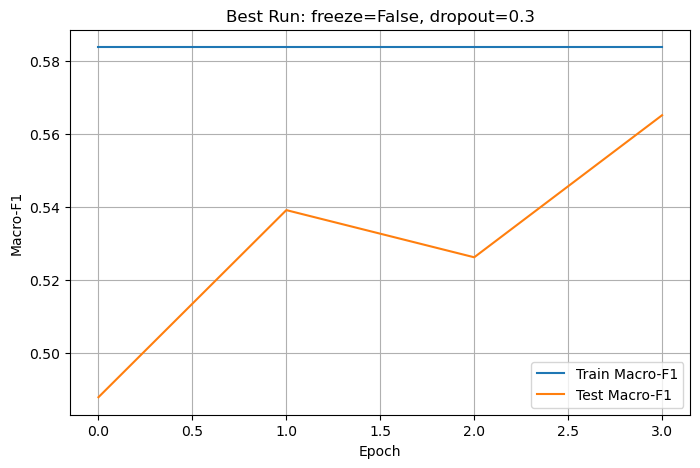

In [202]:
best_run = max(results, key=lambda x: x["test_macro_f1"])

plt.figure(figsize=(8,5))
plt.plot(best_run["train_f1_history"], label="Train Macro-F1")
plt.plot(best_run["test_f1_history"], label="Test Macro-F1")

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title(
    f"Best Run: freeze={best_run['freeze_resnet']}, "
    f"dropout={best_run['dropout']}"
)
plt.legend()
plt.grid(True)
plt.show()

In [203]:
# Best model by test macro F1
best_row = df_results.loc[df_results["test_macro_f1"].idxmax()]
print(best_row)

model                                                        ResNet18
freeze_resnet                                                   False
dropout                                                           0.3
lr_backbone                                                    0.0001
lr_head                                                         0.001
best_epoch                                                          4
train_macro_f1                                                   None
train_acc                                                        None
train_cm                                                         None
test_macro_f1                                                0.565217
test_acc                                                     0.569149
test_cm                    [[86, 33, 28], [28, 56, 30], [16, 27, 72]]
train_f1_history    [0.5838855182597553, 0.5838855182597553, 0.583...
test_f1_history     [0.4877697592247911, 0.539151398321704, 0.5261...
Name: 1, dtype: obje

In [ ]:
# Rank models by test macro F1
df_results.sort_values("test_macro_f1", ascending=False).head(5)

,model,freeze_resnet,dropout,lr_backbone,lr_head,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm,train_f1_history,test_f1_history
1,ResNet18,False,0.3,0.0001,0.001,4,None,None,None,0.565217,0.569149,"[[86, 33, 28], [28, 56, 30], [16, 27, 72]]","[0.5838855182597553, 0.5838855182597553, 0.583...","[0.4877697592247911, 0.539151398321704, 0.5261..."
3,ResNet18,False,0.5,0.0001,0.001,4,None,None,None,0.562060,0.563830,"[[81, 40, 26], [27, 58, 29], [15, 27, 73]]","[0.5923921011205141, 0.5923921011205141, 0.592...","[0.5262921843192232, 0.5234811930888105, 0.550..."
2,ResNet18,True,0.5,NaN,0.001,16,None,None,None,0.539318,0.542553,"[[85, 44, 18], [28, 64, 22], [30, 30, 55]]","[0.45251468379877585, 0.45251468379877585, 0.4...","[0.4497533900821793, 0.3996797849986486, 0.494..."
0,ResNet18,True,0.3,NaN,0.001,3,None,None,None,0.536228,0.539894,"[[85, 36, 26], [31, 60, 23], [26, 31, 58]]","[0.46882453999895884, 0.46882453999895884, 0.4...","[0.46143297883385986, 0.44022079420003296, 0.5..."


In [205]:
# Compare freeze_resnet effects
df_results.groupby("freeze_resnet")["test_macro_f1"].mean()

freeze_resnet
False    0.563638
True     0.537773
Name: test_macro_f1, dtype: float64

In [206]:
# Compare dropout effects
df_results.groupby("dropout")["test_macro_f1"].mean()


dropout
0.3    0.550722
0.5    0.550689
Name: test_macro_f1, dtype: float64

In [207]:
# Best epoch per configuration
df_results.loc[
    df_results.groupby(
        ["freeze_resnet", "dropout"]
    )["test_macro_f1"].idxmax()
]

,model,freeze_resnet,dropout,lr_backbone,lr_head,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm,train_f1_history,test_f1_history
1,ResNet18,False,0.3,0.0001,0.001,4,None,None,None,0.565217,0.569149,"[[86, 33, 28], [28, 56, 30], [16, 27, 72]]","[0.5838855182597553, 0.5838855182597553, 0.583...","[0.4877697592247911, 0.539151398321704, 0.5261..."
3,ResNet18,False,0.5,0.0001,0.001,4,None,None,None,0.562060,0.563830,"[[81, 40, 26], [27, 58, 29], [15, 27, 73]]","[0.5923921011205141, 0.5923921011205141, 0.592...","[0.5262921843192232, 0.5234811930888105, 0.550..."
0,ResNet18,True,0.3,NaN,0.001,3,None,None,None,0.536228,0.539894,"[[85, 36, 26], [31, 60, 23], [26, 31, 58]]","[0.46882453999895884, 0.46882453999895884, 0.4...","[0.46143297883385986, 0.44022079420003296, 0.5..."
2,ResNet18,True,0.5,NaN,0.001,16,None,None,None,0.539318,0.542553,"[[85, 44, 18], [28, 64, 22], [30, 30, 55]]","[0.45251468379877585, 0.45251468379877585, 0.4...","[0.4497533900821793, 0.3996797849986486, 0.494..."


# Clear memory

In [208]:
del model
torch.cuda.empty_cache()
